In [136]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine
from sqlalchemy import text 
from matplotlib.backends.backend_pdf import PdfPages
import sys
import json
import warnings
import traceback
import random
from collections import Counter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [137]:
import sys
print(sys.executable)

D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Scripts\python.exe


In [221]:
def obtener_datos_ejecucion_metrica(execution_name, metric_name, engine):
    """
    Extrae todos los registros de una ejecución y métrica específica.
    """
    SQL = """
        SELECT time,instance,grupo,job,tags,label,metric_value
        FROM metricas_logs
        WHERE execution_name = %s 
          AND metric_name = %s
        ORDER BY time ASC
    """
    
    # Ejecutamos la consulta pasando los parámetros de forma segura
    df = pd.read_sql(SQL, engine, params=(execution_name, metric_name))
    
    # Convertimos la columna time a formato datetime
    df['time'] = pd.to_datetime(df['time'])
    df         = df.sort_values('time')


    inicio_global = df['time'].min()
    df['tiempo_relativo'] = (df['time'] - inicio_global).dt.total_seconds()
        
    return df


In [138]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")

SEED            = os.getenv("SEED")

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

[OK] Conexión establecida con TimescaleDB.


In [139]:
SQL='select distinct(metric_name) from metricas_logs'
df_metric_name = pd.read_sql(SQL, engine)
lista_metric_name=df_metric_name['metric_name'].to_list()


In [140]:
SQL='select distinct(execution_name) from metricas_logs'
df_metric_name = pd.read_sql(SQL, engine)
lista_execution_name=df_metric_name['execution_name'].to_list()

# <span style="color:#2ca02c">1. Analisis de cantidad de datos por ejecucion (execution_name)</span>

In [141]:
# 1. Obtenemos el conteo de registros por ejecución
SQL = 'SELECT execution_name, COUNT(*) AS total_registros FROM metricas_logs GROUP BY execution_name'
df_counts = pd.read_sql(SQL, engine)

# 2. Definimos el umbral (el máximo de registros encontrados)
umbral = df_counts['total_registros'].max()

# 3. Filtramos: seleccionamos las ejecuciones con MENOS registros que el máximo
df_anomalias = df_counts[df_counts['total_registros'] < umbral].copy()

# 4. Añadimos la columna de 'faltante'
df_anomalias['faltante_para_maximo'] = (umbral - df_anomalias['total_registros']).astype(int)

# 5. Añadimos la columna 'max_registros' al final
df_anomalias['max_registros'] = umbral

# 6. Ordenamos y generamos la lista
df_anomalias = df_anomalias.sort_values(by='total_registros', ascending=True)
lista_ejecuciones_descartadas = df_anomalias['execution_name'].tolist()

print(f"📋 Ejecuciones con menos registros que el máximo ({umbral:.0f}):\n")
df_anomalias

📋 Ejecuciones con menos registros que el máximo (23490):



,execution_name,total_registros,faltante_para_maximo,max_registros
24,light-oauth2-data-1719663242.tar,870,22620,23490
131,light-oauth2-data-1720030447.tar,870,22620,23490
3,light-oauth2-data-1719872049.tar,8700,14790,23490
119,light-oauth2-data-1719774843.tar,13485,10005,23490
71,light-oauth2-data-1719749643.tar,18270,5220,23490
...,...,...,...,...
73,light-oauth2-data-1720044850.tar,23055,435,23490
79,light-oauth2-data-1719630850.tar,23055,435,23490
130,light-oauth2-data-1719620054.tar,23055,435,23490
133,light-oauth2-data-1719782050.tar,23055,435,23490


## <span style="color:#2ca02c">2. Analisis de cantidad de datos por metric_name</span>

In [142]:
SQL='select metric_name,count(*) from metricas_logs group by metric_name'
df_counts = pd.read_sql(SQL, engine)


#1.convertir el resutado a dataframe
df_counts['count'] = df_counts['count'].astype(int)

# 2. Calcular la frecuencia y cambiar el nombre de la serie para evitar colisiones
frecuencias = df_counts['count'].value_counts()
frecuencias.name = 'Frecuencia Absoluta'

# 3. Ahora sí hacemos el reset_index de forma segura
tabla_valores_unicos = frecuencias.sort_index().reset_index()

# 4. Renombrar la columna que Pandas saca del índice viejo para que quede impecable
tabla_valores_unicos.columns = ['N', 'Frecuencia Absoluta']

# 5. Calcular el porcentaje que representa sobre el total
total_ejecuciones = len(df_counts)
tabla_valores_unicos['Porcentaje (%)'] = (
    (tabla_valores_unicos['Frecuencia Absoluta'] / total_ejecuciones) * 100
).map('{:.2f}%'.format)

# 6. Mostrar la tabla compacta y real
print(f"📋 RESUMEN DE VALORES ÚNICOS (Total Ejecuciones Analizadas: {total_ejecuciones})\n")
tabla_valores_unicos

📋 RESUMEN DE VALORES ÚNICOS (Total Ejecuciones Analizadas: 435)



,N,Frecuencia Absoluta,Porcentaje (%)
0,7210,435,100.00%


Todas las métricas tienen la misma cantidad de datos

# <span style="color:#2ca02c">3. Revisión de nulos</span>

In [143]:
SQL = """
SELECT 
    COUNT(*) AS total_registros,
    COUNT(*) - COUNT(metric_value) AS nulos_en_valores,
    COUNT(*) - COUNT(label) AS nulos_en_etiquetas,
    COUNT(*) - COUNT(time) AS nulos_en_tiempo,
    COUNT(*) - COUNT(grupo) AS nulos_en_grupo,
    COUNT(*) - COUNT(job) AS nulos_en_job
FROM metricas_logs;
"""

df_nulos = pd.read_sql(SQL, engine)
df_nulos

#result=db.ejecutar_select_generica(SQL)
#print(result)

,total_registros,nulos_en_valores,nulos_en_etiquetas,nulos_en_tiempo,nulos_en_grupo,nulos_en_job
0,3136350,0,0,0,0,0


No tenemos nulos en tiempo, label, metric_value ni job. En el campo grupo la mitad de los datos es nulo.

# <span style="color:#2ca02c">4. Revision de datos de cada métrica</span>

In [144]:

SQL = f"""SELECT 
            metric_name,
            COUNT(*) AS total_registros,
            SUM(CASE WHEN metric_value='nan' THEN 1 ELSE 0 END) AS N_nan,
            ROUND(100.0 * SUM(CASE WHEN  metric_value='nan' THEN 1 ELSE 0 END) / COUNT(*), 2) AS PERC_nan
        FROM metricas_logs
        GROUP BY metric_name
        HAVING SUM(CASE WHEN metric_value='nan' THEN 1 ELSE 0 END) > 0
        ORDER BY metric_name,PERC_nan DESC;
    """
df=pd.read_sql(SQL, engine)
df

,metric_name,total_registros,n_nan,perc_nan


No hay NaN

# <span style="color:#2ca02c">5. Revision de datos de cada métrica</span>

In [146]:

una_ejecucion = lista_execution_name[3]
metric_name   = lista_metric_name[3]

SQL_check = f"""
SELECT COUNT(*) as muestras_metrica_ejecucion
FROM metricas_logs
WHERE execution_name = '{una_ejecucion}'
  AND metric_name = '{metric_name}';
"""

df_var = pd.read_sql(SQL_check, engine)
df_var

,muestras_metrica_ejecucion
0,51


In [147]:
lista_metricas_filtradas=lista_metric_name.copy()


In [148]:
len(lista_metricas_filtradas)

435

In [149]:
# Tu lista de métricas filtradas

# Convertimos la lista a una tupla (es el formato que espera SQL para el operador IN)
tuple_metricas = tuple(lista_metricas_filtradas)

# Usamos %s como marcador de posición (el driver de SQL hará el escape correcto)
# Nota: Si la lista solo tiene un elemento, la tupla debe definirse como (elemento,)
SQL = """
SELECT 
    metric_name,
    COUNT(*) AS N_muestras,
    MIN(metric_value) AS MIN,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY metric_value) AS Q1,
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY metric_value) AS Q2,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY metric_value) AS Q3,
    MAX(metric_value) AS MAX,
    STDDEV(metric_value) AS STD_DEV
FROM 
    metricas_logs
WHERE 
    metric_name IN %(metricas)s
GROUP BY 
    metric_name;
"""

# Lanzamos la consulta pasando el diccionario de parámetros
df_resumen_estadistico = pd.read_sql_query(SQL, engine, params={'metricas': tuple_metricas})
df_resumen_estadistico

,metric_name,n_muestras,min,q1,q2,q3,max,std_dev
0,light-oauth2-oauth2-client-1(0),7210,0.0,3.0,7.0,14.0,675.0,60.543685
1,light-oauth2-oauth2-client-1(1),7210,0.0,382.0,638.0,847.0,1209.0,263.323124
2,light-oauth2-oauth2-client-1(10),7210,0.0,19.0,26.0,34.0,83.0,11.421093
3,light-oauth2-oauth2-client-1(11),7210,0.0,11.0,16.0,21.0,55.0,7.408461
4,light-oauth2-oauth2-client-1(12),7210,0.0,21.0,34.0,46.0,75.0,14.915326
...,...,...,...,...,...,...,...,...
430,light-oauth2-oauth2-user-1(5),7210,0.0,53.0,74.0,97.0,239.0,31.599588
431,light-oauth2-oauth2-user-1(6),7210,0.0,28.0,41.0,54.0,115.0,18.374074
432,light-oauth2-oauth2-user-1(7),7210,2.0,32.0,41.0,52.0,100.0,14.357940
433,light-oauth2-oauth2-user-1(8),7210,2.0,19.0,25.0,32.0,63.0,9.381790


In [152]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_resumen_estadistico)

,metric_name,n_muestras,min,q1,q2,q3,max,std_dev
0,light-oauth2-oauth2-client-1(0),7210,0.0,3.00,7.0,14.00,675.0,60.543685
1,light-oauth2-oauth2-client-1(1),7210,0.0,382.00,638.0,847.00,1209.0,263.323124
2,light-oauth2-oauth2-client-1(10),7210,0.0,19.00,26.0,34.00,83.0,11.421093
3,light-oauth2-oauth2-client-1(11),7210,0.0,11.00,16.0,21.00,55.0,7.408461
4,light-oauth2-oauth2-client-1(12),7210,0.0,21.00,34.0,46.00,75.0,14.915326
5,light-oauth2-oauth2-client-1(13),7210,0.0,21.00,34.0,46.00,78.0,14.844263
6,light-oauth2-oauth2-client-1(14),7210,0.0,0.00,0.0,0.00,41.0,4.101608
7,light-oauth2-oauth2-client-1(15),7210,0.0,9.00,12.0,15.00,35.0,5.117621
8,light-oauth2-oauth2-client-1(16),7210,0.0,0.00,0.0,0.00,24.0,2.028374
9,light-oauth2-oauth2-client-1(17),7210,0.0,0.00,0.0,0.00,21.0,1.536755


In [153]:
df_resumen_estadistico.to_parquet(f'{FOLDER_SALIDA}/resumen_estadistico(metricas_logs).parquet', index=False,engine='fastparquet')

In [24]:
#df_resumen_estadistico = pd.read_parquet(f'{FOLDER_SALIDA}/resumen_estadistico(metricas_logs).parquet', engine='fastparquet')

In [154]:
metricas_con_std_dev_nulo     = df_resumen_estadistico['std_dev']==0
df_metricas_filtradas = df_resumen_estadistico[~metricas_con_std_dev_nulo].reset_index(drop=True)
lista_metricas_con_std_dev_nulo = df_resumen_estadistico.loc[metricas_con_std_dev_nulo, 'metric_name'].tolist()

In [155]:
with open(f'result/lista_metricas_con_std_dev_nulo(metricas_logs).json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_con_std_dev_nulo, f, ensure_ascii=False, indent=4)

In [157]:
len(lista_metricas_con_std_dev_nulo)

67

In [70]:
df_metricas_filtradas

,metric_name,n_muestras,min,q1,q2,q3,max,std_dev
0,light-oauth2-oauth2-client-1(0),2233,0.0,2.0,7.0,14.0,590.0,62.741847
1,light-oauth2-oauth2-client-1(1),2233,0.0,400.0,660.0,851.0,1179.0,258.234728
2,light-oauth2-oauth2-client-1(10),2233,0.0,20.0,27.0,35.0,83.0,11.393291
3,light-oauth2-oauth2-client-1(11),2233,0.0,11.0,16.0,21.0,51.0,7.335767
4,light-oauth2-oauth2-client-1(12),2233,0.0,21.0,35.0,46.0,71.0,14.775243
...,...,...,...,...,...,...,...,...
356,light-oauth2-oauth2-user-1(5),2233,0.0,51.0,74.0,96.0,239.0,31.678803
357,light-oauth2-oauth2-user-1(6),2233,0.0,27.0,41.0,54.0,115.0,18.647916
358,light-oauth2-oauth2-user-1(7),2233,2.0,32.0,41.0,51.0,97.0,14.436198
359,light-oauth2-oauth2-user-1(8),2233,2.0,18.0,25.0,31.0,61.0,9.548360


In [158]:
lista_metricas_filtadas=df_metricas_filtradas['metric_name'].to_list()
df_metricas_filtradas.to_parquet(f'{FOLDER_SALIDA}/df_metricas_filtradas(metricas_logs).parquet', index=False,engine='fastparquet')

In [159]:
len(lista_metricas_filtadas)

368

In [72]:
with open(f'result/lista_metricas_filtradas(metricas_logs).json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_filtadas, f, ensure_ascii=False, indent=4)

In [160]:
# 1. Configuración de estilo y limpieza de avisos
sns.set_theme(style="whitegrid")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Inicializamos la estructura para guardar las métricas sin variación
metricas_estaticas = set()

nombre_pdf = "result/informe_estructurado_metricas_logs.pdf"
total_metricas = len(lista_metricas_filtadas)

print(f"🚀 Iniciando exportación masiva a {nombre_pdf}...")

# 2. Abrimos el contexto del PDF
with PdfPages(nombre_pdf) as pdf:
    
    for i, una_metrica in enumerate(lista_metricas_filtadas, 1):
        
        # 🚀 MENSAJE INTERACTIVO: Muestra el progreso actual sobreescribiendo la misma línea
        # Limitamos visualmente el nombre de la métrica a 45 caracteres para mantener limpia la consola
        sys.stdout.write(f"\r🔄 [{i}/{total_metricas}] Procesando: {una_metrica[:45]}...".ljust(80))
        sys.stdout.flush()
        
        # Query para traer los datos de la métrica actual
        SQL = f"""
        SELECT metric_value, label 
        FROM metricas_logs
        WHERE metric_name = '{una_metrica}';
        """
        
        try:
            df_var = pd.read_sql(text(SQL), engine)
            
            # Saltamos si la métrica está vacía
            if df_var.empty:
                continue
                
            df_var['metric_value'] = df_var['metric_value'].astype(float)
            df_var['label'] = df_var['label'].astype(str)

            # DETECCIÓN DE MÉTRICAS INVARIANTES:
            # Si todos los valores de la columna son idénticos, la guardamos 
            if df_var['metric_value'].nunique() <= 1:
                metricas_estaticas.add(una_metrica)
                #continue

            # Mapeo binario para el Histograma (correct vs el resto)
            df_var['label_binaria'] = df_var['label'].apply(lambda x: 'correct' if x == 'correct' else 'anomaly')

            orden_boxplot = list(df_var['label'].unique())

            # 3. Creamos la figura optimizada para el folio
            fig, axes = plt.subplots(2, 1, figsize=(11, 16), gridspec_kw={'height_ratios': [1, 3]})

            # --- GRÁFICO 1: HISTOGRAMA BINARIO (Arriba) ---
            sns.histplot(
                data=df_var, 
                x='metric_value', 
                hue='label_binaria',  
                hue_order=['correct', 'anomaly'],
                palette={'correct': '#2ecc71', 'anomaly': '#e74c3c'}, 
                kde=True, 
                ax=axes[0],
                element='step',
                stat='density',  
                common_norm=False,
                legend=True  
            )
            axes[0].set_title('Distribución Comparativa Binaria (Histograma)', fontsize=12, fontweight='bold')
            axes[0].set_xlabel('Valor de la Métrica')
            axes[0].set_ylabel('Densidad')

            # --- GRÁFICO 2: BOXPLOT MULTI-ETIQUETA ORDENADO (Abajo) ---
            sns.boxplot(
                data=df_var, 
                x='metric_value', 
                y='label',         
                order=orden_boxplot,  
                orient='h',
                palette='tab20', 
                ax=axes[1],
                hue='label',
                legend=False,
                width=0.7,          
                fliersize=3
            )
            axes[1].set_title('Dispersión Detallada por Escenario / Ataque', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Valor de la Métrica')
            axes[1].set_ylabel('Tipo de Escenario (Label)')
            axes[1].tick_params(axis='y', labelsize=8)

            # Título de la página actual
            fig.suptitle(f"📊 [Métrica {i}] ANÁLISIS DETALLADO: {una_metrica.upper()}", fontsize=14, fontweight='bold', y=1.01)
            
            plt.tight_layout()
            
            # Guardamos la página en el PDF y liberamos memoria
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
            

    
        except Exception as e:
            error_details = traceback.format_exc()
            fig_err, ax_err = plt.subplots(figsize=(11, 8.5))
            fig_err.suptitle(f"⚠️ ERROR EN MÉTRICA: {una_metrica.upper()}", fontsize=14, fontweight='bold', color='darkred')
            ax_err.text(0.05, 0.95, f"Ocurrió un error al procesar:\n{str(e)}\n\nDetalle técnico (Traceback):", 
                        fontsize=10, fontweight='bold', va='top', transform=ax_err.transAxes)
            ax_err.text(0.05, 0.85, error_details, fontsize=8, va='top', family='monospace', transform=ax_err.transAxes)         
            ax_err.axis('off')
            
            pdf.savefig(fig_err, bbox_inches='tight')
            plt.close(fig_err)
            
            print(f"\n❌ Métrica {una_metrica} falló. Error registrado en el PDF.")

# Un salto de línea final para limpiar la consola al terminar el bucle
print("\n")
print(f"🎉 ¡Hecho! El archivo '{nombre_pdf}' se ha guardado correctamente.")
print(f"🚫 Lista completa de métricas invariantes detectadas: {list(metricas_estaticas)}")

🚀 Iniciando exportación masiva a result/informe_estructurado_metricas_logs.pdf...
🔄 [368/368] Procesando: light-oauth2-oauth2-user-1(9)...                       

🎉 ¡Hecho! El archivo 'result/informe_estructurado_metricas_logs.pdf' se ha guardado correctamente.
🚫 Lista completa de métricas invariantes detectadas: []


Los boxplot indican que hay métricas que por si solas pueden  servir para identificar una anomalía concreta

In [161]:
# Lista para almacenar los diccionarios con los resultados de cada métrica
resultados_monotonia = []

print(f"⏳ Auditando monotonía para las {len(lista_metricas_filtadas)} métricas filtradas...")

# 1. Bucle que recorre únicamente tu lista de métricas limpias
for i, metrica in enumerate(lista_metricas_filtadas):
    texto_progreso = f'Calculando monotonia de métrica ({metrica})'
    print(f"\r{texto_progreso}".ljust(100), end='', flush=True)
    
    # Query optimizada: Traemos el valor y la ejecución ordenados cronológicamente
    SQL = f"""
    SELECT execution_name, metric_value 
    FROM metricas_logs
    WHERE metric_name = '{metrica}'
    ORDER BY execution_name, time ASC;
    """
    
    df_m = pd.read_sql(text(SQL), engine)
    
    if df_m.empty:
        continue
        
    df_m['metric_value'] = df_m['metric_value'].astype(float)
    
    # 2. Agrupamos por ejecución y calculamos la diferencia con el registro anterior
    # Usamos .diff() dentro de cada grupo para no mezclar ejecuciones distintas
    df_m['diferencia'] = df_m.groupby('execution_name')['metric_value'].diff()
    
    # Eliminamos los NaNs que genera el .diff() en la primera fila de cada ejecución
    df_m_limpio = df_m.dropna(subset=['diferencia'])
    
    # 3. Contamos ejecuciones totales implicadas en esta métrica
    lista_ejecuciones = df_m['execution_name'].unique()
    total_ejecuciones = len(lista_ejecuciones)
    
    # 4. Evaluamos cuáles de esas ejecuciones son monótonas
    # Una ejecución es monótona si TODAS sus diferencias son mayores o iguales a 0
    ejecuciones_monotonas = 0
    for ejecucion in lista_ejecuciones:
        df_ejec = df_m_limpio[df_m_limpio['execution_name'] == ejecucion]
        if (df_ejec['diferencia'] >= 0).all():
            ejecuciones_monotonas += 1
            
    # 5. Guardamos el balance de la métrica actual
    es_monotona_100 = (ejecuciones_monotonas == total_ejecuciones)
    
    resultados_monotonia.append({
        'metric_name': metrica,
        'total_ejecuciones': total_ejecuciones,
        'ejecuciones_monotonas': ejecuciones_monotonas,
        'es_monotona_100': es_monotona_100,
        'clasificacion_tipo': 'Monótona Creciente (Counter) ✅' if es_monotona_100 else 'Variable (Gauge) ❌'
    })
    
    # Pequeño chivato para ver el progreso en el Notebook
    if (i + 1) % 5 == 0 or (i + 1) == len(lista_metricas_filtadas):
        print(f"   ➔ Procesadas {i + 1}/{len(lista_metricas_filtadas)} métricas.")

# 6. Construimos el DataFrame final de resumen
df_resumen_monotonia = pd.DataFrame(resultados_monotonia)

# Ordenamos para tener los contadores (Counters) arriba del todo
df_resumen_monotonia = df_resumen_monotonia.sort_values(by='es_monotona_100', ascending=False).reset_index(drop=True)

print("\n🎉 ¡Auditoría completada con éxito!")
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None, 
                       'display.max_colwidth', None):
    
    display(df_resumen_monotonia)

⏳ Auditando monotonía para las 368 métricas filtradas...
Calculando monotonia de métrica (light-oauth2-oauth2-client-1(12))                                    ➔ Procesadas 5/368 métricas.
Calculando monotonia de métrica (light-oauth2-oauth2-client-1(17))                                    ➔ Procesadas 10/368 métricas.
Calculando monotonia de métrica (light-oauth2-oauth2-client-1(21))                                    ➔ Procesadas 15/368 métricas.
Calculando monotonia de métrica (light-oauth2-oauth2-client-1(26))                                    ➔ Procesadas 20/368 métricas.
Calculando monotonia de métrica (light-oauth2-oauth2-client-1(30))                                    ➔ Procesadas 25/368 métricas.
Calculando monotonia de métrica (light-oauth2-oauth2-client-1(35))                                    ➔ Procesadas 30/368 métricas.
Calculando monotonia de métrica (light-oauth2-oauth2-client-1(4))                                     ➔ Procesadas 35/368 métricas.
Calculando monotonia

,metric_name,total_ejecuciones,ejecuciones_monotonas,es_monotona_100,clasificacion_tipo
0,light-oauth2-oauth2-client-1(0),146,2,False,Variable (Gauge) ❌
1,light-oauth2-oauth2-token-1(125),147,140,False,Variable (Gauge) ❌
2,light-oauth2-oauth2-token-1(137),147,146,False,Variable (Gauge) ❌
3,light-oauth2-oauth2-token-1(133),147,146,False,Variable (Gauge) ❌
4,light-oauth2-oauth2-token-1(132),147,146,False,Variable (Gauge) ❌
5,light-oauth2-oauth2-token-1(130),147,136,False,Variable (Gauge) ❌
6,light-oauth2-oauth2-token-1(13),147,2,False,Variable (Gauge) ❌
7,light-oauth2-oauth2-token-1(129),147,134,False,Variable (Gauge) ❌
8,light-oauth2-oauth2-token-1(128),147,146,False,Variable (Gauge) ❌
9,light-oauth2-oauth2-token-1(127),147,146,False,Variable (Gauge) ❌


In [162]:
df_resumen_monotonia.to_parquet(f'{FOLDER_SALIDA}/df_resumen_monotonia(metricas_logs).parquet', index=False,engine='fastparquet')

In [163]:
lista_metricas_monotonas=df_resumen_monotonia[df_resumen_monotonia['es_monotona_100']]['metric_name'].to_list()

In [164]:
with open(f'result/lista_metricas_monotonas(metricas_logs).json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_monotonas, f, ensure_ascii=False, indent=4)

In [165]:
len(lista_metricas_monotonas)

0

In [166]:
df_analisis_metricas                     = pd.DataFrame({'metric_name': lista_metric_name})
df_analisis_metricas['std_dev_nulo']     = df_analisis_metricas['metric_name'].isin(lista_metricas_con_std_dev_nulo)
df_analisis_metricas['metrica_monotona'] = df_analisis_metricas['metric_name'].isin(lista_metricas_monotonas)


In [167]:
def clasificar_metrica(row):
    if row['std_dev_nulo']:
        result=''
    # elif row['valores_NAN']:
    #     result=''
    elif not row['metrica_monotona']:
        result='normal'
    elif row['diff_invariante']:
        result=''
    else:
        result='diff'
    return result

def nombre_metrica(row):
    if row['clasificacion']=='normal':
        result=row['metric_name']
    elif row['clasificacion']=='diff':
        result=row['metric_name']+'_diff'
    else:
        result=''
    return result
        
        

df_analisis_metricas['clasificacion'] = df_analisis_metricas.apply(clasificar_metrica, axis=1)
df_analisis_metricas['metric_name_sel'] = df_analisis_metricas.apply(nombre_metrica, axis=1)
        

In [168]:
df_analisis_metricas

,metric_name,std_dev_nulo,metrica_monotona,clasificacion,metric_name_sel
0,light-oauth2-oauth2-client-1(0),False,False,normal,light-oauth2-oauth2-client-1(0)
1,light-oauth2-oauth2-client-1(1),False,False,normal,light-oauth2-oauth2-client-1(1)
2,light-oauth2-oauth2-client-1(10),False,False,normal,light-oauth2-oauth2-client-1(10)
3,light-oauth2-oauth2-client-1(11),False,False,normal,light-oauth2-oauth2-client-1(11)
4,light-oauth2-oauth2-client-1(12),False,False,normal,light-oauth2-oauth2-client-1(12)
...,...,...,...,...,...
430,light-oauth2-oauth2-user-1(5),False,False,normal,light-oauth2-oauth2-user-1(5)
431,light-oauth2-oauth2-user-1(6),False,False,normal,light-oauth2-oauth2-user-1(6)
432,light-oauth2-oauth2-user-1(7),False,False,normal,light-oauth2-oauth2-user-1(7)
433,light-oauth2-oauth2-user-1(8),False,False,normal,light-oauth2-oauth2-user-1(8)


In [169]:
df_analisis_metricas['clasificacion'].value_counts()

clasificacion
normal    368
           67
Name: count, dtype: int64

In [170]:
df_analisis_metricas.to_parquet(f'{FOLDER_SALIDA}/analisis_metricas(metricas_logs).parquet', index=False,engine='fastparquet')

# <span style="color:#2ca02c">5. Análisis de correlacion y redundancia (multicolinealidad)</span>

In [190]:
len(lista_metricas_filtadas)

368

In [175]:
NUM_EJECUCIONES_PRUEBA = 100
lista_ejecuciones_sel = np.random.choice(lista_execution_name, size=NUM_EJECUCIONES_PRUEBA, replace=False).tolist()
# lista_metricas_sel    = df_analisis_metricas[df_analisis_metricas['metric_name_sel']!='']['metric_name'].to_list()
lista_metricas_sel    = lista_metricas_filtadas.copy()
#lista_metricas_sel_diff=  df_analisis_metricas[df_analisis_metricas['clasificacion']=='diff']['metric_name'].to_list()
lista_metricas_sel_diff =[]
tupla_ejecuciones = tuple(lista_ejecuciones_sel)
tupla_metricas = tuple(lista_metricas_sel)

In [176]:
SQL = f"""
SELECT execution_name, time, metric_name, metric_value
FROM metricas_logs
WHERE execution_name IN {tupla_ejecuciones}
  AND metric_name IN {tupla_metricas}
  AND label = 'correct'
ORDER BY execution_name, metric_name, time ASC;
"""

print("⏳ Extrayendo datos de la base de datos...")
df = pd.read_sql(text(SQL), engine)

⏳ Extrayendo datos de la base de datos...


In [177]:
df_pivot = df.pivot(
    index=['execution_name', 'time'],
    columns='metric_name',
    values='metric_value'
)

In [178]:
df_procesado = df_pivot.copy()
for metrica in lista_metricas_sel_diff:
    if metrica in df_procesado.columns:
        # Calculamos el delta temporal manteniendo el aislamiento por experimento
        df_procesado[f'{metrica}_diff'] = df_procesado.groupby('execution_name')[metrica].diff()
        df_procesado.drop(metrica, axis=1, inplace=True)   #borramos la metrica original
        
df_procesado.dropna(inplace=True)  #borramos todas las filas que tienen NaN, corresponden a la primera muestra





In [179]:
corr_matrix = df_procesado.corr().abs()

# 2. Extraemos el triángulo superior para evitar parejas duplicadas
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Filtramos las que superen el umbral crítico del 95%
UMBRAL = 0.95
pares_redundantes = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] > UMBRAL
]

# 4. Construimos el DataFrame de resultados
df_redundancia = pd.DataFrame(pares_redundantes, columns=['Metrica_A', 'Metrica_B', 'Correlacion'])
df_redundancia = df_redundancia.sort_values(by='Correlacion', ascending=False).reset_index(drop=True)

In [180]:
df_redundancia

,Metrica_A,Metrica_B,Correlacion
0,light-oauth2-oauth2-refresh-token-1(3),light-oauth2-oauth2-refresh-token-1(2),0.999325
1,light-oauth2-oauth2-token-1(6),light-oauth2-oauth2-token-1(2),0.999129
2,light-oauth2-oauth2-refresh-token-1(4),light-oauth2-oauth2-refresh-token-1(2),0.998940
3,light-oauth2-oauth2-refresh-token-1(4),light-oauth2-oauth2-refresh-token-1(3),0.998113
4,light-oauth2-oauth2-refresh-token-1(5),light-oauth2-oauth2-refresh-token-1(1),0.997425
...,...,...,...
93,light-oauth2-oauth2-code-1(3),light-oauth2-oauth2-code-1(13),0.954484
94,light-oauth2-oauth2-token-1(38),light-oauth2-oauth2-code-1(44),0.953119
95,light-oauth2-oauth2-code-1(3),light-oauth2-oauth2-code-1(15),0.952428
96,light-oauth2-oauth2-code-1(3),light-oauth2-oauth2-code-1(12),0.952313


In [181]:
df_redundancia.to_parquet(f'{FOLDER_SALIDA}/df_redundancia(metricas_logs).parquet', index=False,engine='fastparquet')

In [198]:
lista_metricas_redundantes_B =list(set(df_redundancia['Metrica_B'].to_list()  ))
lista_metricas_redundantes_A =list(set(df_redundancia['Metrica_A'].to_list()  ))

In [202]:
len(lista_metricas_redundantes_A)

37

In [203]:
len(lista_metricas_redundantes_B)

37

In [204]:
lista_metricas_redundantes = lista_metricas_redundantes_A

In [214]:
lista_metricas_filtadas2 = [
    metrica for metrica in lista_metricas_filtadas 
    if metrica not in lista_metricas_redundantes
]

In [215]:
len(lista_metricas_filtadas2)

331

In [205]:
with open(f'result/lista_metricas_redundantes(metricas_logs).json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_redundantes, f, ensure_ascii=False, indent=4)

In [206]:
df_analisis_metricas['redundante']=df_analisis_metricas['metric_name_sel'].isin(lista_metricas_redundantes)

0

In [209]:
df_analisis_metricas.loc[df_analisis_metricas['redundante'] & (df_analisis_metricas['metric_name_sel']!='') , 'metric_name_sel'] = ''

In [210]:
df_analisis_metricas.to_parquet(f'{FOLDER_SALIDA}/analisis_metricas(metricas_logs).parquet', index=False,engine='fastparquet')

In [211]:
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None, 
                       'display.max_colwidth', None):
    display(df_analisis_metricas)

,metric_name,std_dev_nulo,metrica_monotona,clasificacion,metric_name_sel,redundante
0,light-oauth2-oauth2-client-1(0),False,False,normal,light-oauth2-oauth2-client-1(0),False
1,light-oauth2-oauth2-client-1(1),False,False,normal,light-oauth2-oauth2-client-1(1),False
2,light-oauth2-oauth2-client-1(10),False,False,normal,light-oauth2-oauth2-client-1(10),False
3,light-oauth2-oauth2-client-1(11),False,False,normal,light-oauth2-oauth2-client-1(11),False
4,light-oauth2-oauth2-client-1(12),False,False,normal,,False
5,light-oauth2-oauth2-client-1(13),False,False,normal,,False
6,light-oauth2-oauth2-client-1(14),False,False,normal,light-oauth2-oauth2-client-1(14),False
7,light-oauth2-oauth2-client-1(15),False,False,normal,light-oauth2-oauth2-client-1(15),False
8,light-oauth2-oauth2-client-1(16),False,False,normal,light-oauth2-oauth2-client-1(16),False
9,light-oauth2-oauth2-client-1(17),False,False,normal,light-oauth2-oauth2-client-1(17),False


In [212]:
df_analisis_metricas[   df_analisis_metricas['redundante']==False  ]['clasificacion'].value_counts()# pendiente revisar esto ultimo porque creo que no lo he construido bien

clasificacion
normal    368
           67
Name: count, dtype: int64

In [213]:
len( df_analisis_metricas[   df_analisis_metricas['redundante']==False  ] )

435

In [252]:
len(lista_metricas_filtadas2)

331

In [253]:
with open(f'result/lista_metricas_filtradas(metricas_logs).json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_filtadas2, f, ensure_ascii=False, indent=4)

# <span style="color:#2ca02c">9. Detección de outliers</span>

## <span style="color:#2ca02c">9a. Detección de outliers revsando métricas aisladas</span>

In [131]:
df_analisis_metricas

,metric_name,std_dev_nulo,metrica_monotona,clasificacion,metric_name_sel,redundante
0,light-oauth2-oauth2-client-1(0),False,False,normal,light-oauth2-oauth2-client-1(0),False
1,light-oauth2-oauth2-client-1(1),False,False,normal,light-oauth2-oauth2-client-1(1),False
2,light-oauth2-oauth2-client-1(10),False,False,normal,light-oauth2-oauth2-client-1(10),False
3,light-oauth2-oauth2-client-1(11),False,False,normal,light-oauth2-oauth2-client-1(11),False
4,light-oauth2-oauth2-client-1(12),False,False,normal,,False
...,...,...,...,...,...,...
430,light-oauth2-oauth2-user-1(5),False,False,normal,light-oauth2-oauth2-user-1(5),False
431,light-oauth2-oauth2-user-1(6),False,False,normal,light-oauth2-oauth2-user-1(6),False
432,light-oauth2-oauth2-user-1(7),False,False,normal,light-oauth2-oauth2-user-1(7),False
433,light-oauth2-oauth2-user-1(8),False,False,normal,light-oauth2-oauth2-user-1(8),False


In [ ]:
df_analisis_metricas.to_parquet(f'{FOLDER_SALIDA}/analisis_metricas(metricas_logs).parquet', index=False,engine='fastparquet')

In [110]:
#lista_ejecuciones_sel = lista_execution_name.copy()
df_analisis_metricas = pd.read_parquet(f'{FOLDER_SALIDA}/analisis_metricas(metricas_logs).parquet', engine='fastparquet')



In [216]:
#lista_metricas_sel=df_analisis_metricas[   df_analisis_metricas['metric_name_sel']!=''  ]['metric_name'].tolist()
lista_metricas_sel = lista_metricas_filtadas2.copy()

In [217]:
len(lista_metricas_sel)

331

In [218]:
una_metrica    = lista_metricas_sel[1]

In [219]:
print('=============')
df_filtrado = df_analisis_metricas[  df_analisis_metricas['metric_name']==una_metrica   ]
clasificacion = df_filtrado.iloc[0]['clasificacion']
metric_name_sel = df_filtrado.iloc[0]['metric_name_sel']
display(df_filtrado)
print(f'clasificacion   = {clasificacion}')
print(f'metric_name_sel = {metric_name_sel}')

,metric_name,std_dev_nulo,metrica_monotona,clasificacion,metric_name_sel,redundante
1,light-oauth2-oauth2-client-1(1),False,False,normal,light-oauth2-oauth2-client-1(1),False


clasificacion   = normal
metric_name_sel = light-oauth2-oauth2-client-1(1)


In [46]:
#Revisamos cuantas muestras tienen los datos 'correct' de cada ejecucion de una de las metricas

INTERVALO_MUESTREO = 5
lista_series=[]
N=0
for una_ejecucion in lista_ejecuciones_sel:
    N+=1
    print(f'execution_name = {una_ejecucion}   | N={N:04d}  | metric_name = {una_metrica}'.ljust(200),end='\r')
    df_serie       = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
    df_interpolado = interpolar(df_serie,INTERVALO_MUESTREO)
    df_interpolado_correct=df_interpolado[  df_interpolado['label']=='correct'  ]
    lista_valores_tmp = df_interpolado_correct['metric_value'].tolist()
    lista_series.append(lista_valores_tmp)

print()
print('=================')
longitudes = [len(serie) for serie in lista_series]

todos_los_valores = [valor for serie in lista_series for valor in serie]

# 2. Contamos cuántas veces aparece cada longitud
conteo_longitudes = Counter(longitudes)

# 3. Imprimimos el resultado de forma ordenada
print("Distribución de longitudes de las series:")
for longitud in sorted(conteo_longitudes.keys()):
    print(f"Longitud {longitud}: {conteo_longitudes[longitud]} ejecuciones")

execution_name = light-oauth2-data-1725869703.tar   | N=1732  | metric_name = go_gc_duration_seconds_count                                                                                              
Distribución de longitudes de las series:
Longitud 13: 1731 ejecuciones
Longitud 15: 1 ejecuciones


<span style="color:#2ca02c">Todas las ejecuciones tienen 13 muestras salvo una, usaremos solo  las de 13 para descartar outliers</span>

In [223]:
longitud_correct=13
INTERVALO_MUESTREO=5
nombre_pdf = "result/visualizacion_outliers(metricas_logs).pdf"
N_metrica=0
with PdfPages(nombre_pdf) as pdf:
    for i, una_metrica in enumerate(lista_metricas_sel, 1):
        N_metrica+=1
        df_sel = df_analisis_metricas[df_analisis_metricas['metric_name'] == una_metrica]
        clasificacion = df_sel.iloc[0]['clasificacion']
        metric_name_sel = df_sel.iloc[0]['metric_name_sel']

        lista_series = []
        # 1. Recolectamos todas las series PRIMERO
        for N, una_ejecucion in enumerate(lista_ejecuciones_sel, 1):
            print(f'Procesando: {una_metrica:50s} | Ejecucción: {N:04d}/{len(lista_ejecuciones_sel)}   | N_Metrica: {N_metrica:04d}', end='\r')
            
            df_serie = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
            #df_interpolado = interpolar(df_serie, INTERVALO_MUESTREO)
            df_interpolado = df_serie
            lista_valores_tmp = df_interpolado[df_interpolado['label'] == 'correct']['metric_value'].tolist()

            
            lista_series.append(lista_valores_tmp[:longitud_correct])

        # 2. Creamos el DataFrame fuera del bucle de ejecuciones
        df = pd.DataFrame(lista_series)
        
        # Aplicar diff si corresponde
        if clasificacion == 'diff':
            df = df.diff(axis=1).dropna(axis=1)

        # 3. Centrado
        df_centrado = df.sub(df.mean(axis=1), axis=0)

        # 4. Generación del gráfico y guardado en PDF
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)
        
        # Gráficos... (mantiene tu lógica anterior usando ax1 y ax2)
        ax1.plot(df.T, color='gray', alpha=0.1, linewidth=1)
        ax1.plot(df.mean(axis=0), color='red', linewidth=2)
        ax1.set_title(f"Valores Absolutos: {metric_name_sel}")
        ax1.grid(True, axis='x', linestyle='--', alpha=0.3)
        
        ax2.plot(df_centrado.T, color='gray', alpha=0.1, linewidth=1)
        ax2.plot(df_centrado.mean(axis=0), color='blue', linewidth=2)
        ax2.set_title(f"Series Centradas: {metric_name_sel}")
        ax2.grid(True, axis='x', linestyle='--', alpha=0.3)

        plt.tight_layout()
        pdf.savefig(fig) # GUARDAR EN PDF
        plt.close(fig)   # Liberar memoria importante
        #print(f"\nGráfico para {una_metrica} guardado en PDF.")

Procesando: light-oauth2-oauth2-user-1(9) | Ejecucción: 0100/100   | N_Metrica: 03312444 01818

In [226]:
longitud_correct=13
INTERVALO_MUESTREO=5
lista_outliers=[]
nombre_pdf = "result/visualizacion_outliers(metricas_logs).pdf"
N_metrica=0
with PdfPages(nombre_pdf) as pdf:
    for i, una_metrica in enumerate(lista_metricas_sel, 1):
        N_metrica+=1
        df_sel = df_analisis_metricas[df_analisis_metricas['metric_name'] == una_metrica]
        clasificacion = df_sel.iloc[0]['clasificacion']
        metric_name_sel = df_sel.iloc[0]['metric_name_sel']

        lista_series = []
        # 1. Recolectamos todas las series PRIMERO
        for N, una_ejecucion in enumerate(lista_ejecuciones_sel, 1):
            print(f'Procesando: {una_metrica} | Ejecucción: {N:04d}/{len(lista_ejecuciones_sel)}   | N_Metrica: {N_metrica:04d}', end='\r')
            
            df_serie = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
            #df_interpolado = interpolar(df_serie, INTERVALO_MUESTREO)
            df_interpolado = df_serie.copy()
            lista_valores_tmp = df_interpolado[df_interpolado['label'] == 'correct']['metric_value'].tolist()
            
            # if len(lista_valores_tmp) == 13:
            #     lista_series.append(lista_valores_tmp)
            lista_series.append(lista_valores_tmp[:longitud_correct])                

        # 2. Creamos el DataFrame fuera del bucle de ejecuciones
        df = pd.DataFrame(lista_series)
        
        # Aplicar diff si corresponde
        if clasificacion == 'diff':
            df = df.diff(axis=1).dropna(axis=1)

        # 3. Centrado
        df_centrado = df.sub(df.mean(axis=1), axis=0)

        # 4. Generación del gráfico y guardado en PDF
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)
        
        # Gráficos... (mantiene tu lógica anterior usando ax1 y ax2)
        ax1.plot(df.T, color='gray', alpha=0.1, linewidth=1)
        ax1.plot(df.mean(axis=0), color='red', linewidth=2)
        ax1.set_title(f"Valores Absolutos: {metric_name_sel}")
        ax1.grid(True, axis='x', linestyle='--', alpha=0.3)
        
        ax2.plot(df_centrado.T, color='gray', alpha=0.1, linewidth=1)
        ax2.plot(df_centrado.mean(axis=0), color='blue', linewidth=2)
        ax2.set_title(f"Series Centradas: {metric_name_sel}")
        ax2.grid(True, axis='x', linestyle='--', alpha=0.3)

        plt.tight_layout()
        pdf.savefig(fig) # GUARDAR EN PDF
        plt.close(fig)   # Liberar memoria importante

        #calculamos desviaciones y marcaremos reires que se desvian demasiado del promedio para marcarlas como outliers
        desviacion_global = df_centrado.stack().std()
        umbral_real = 3 * desviacion_global
        outliers = df_centrado[(df_centrado.abs() > umbral_real).any(axis=1)] 
        list_index_outlier=df_centrado[(df_centrado.abs() > umbral).any(axis=1)].index.tolist()   #identificamos las ejecuciones como outlier si alguno de sus puntos se desvia demasaido el promedio
        for index_outlier in list_index_outlier:
            reg_outlier={}
            reg_outlier['execution_name'] = lista_ejecuciones_sel[index_outlier]
            reg_outlier['metric_name']    = una_metrica
            lista_outliers.append(reg_outlier)
            
        # if N_metrica>=5:
        #     break


Procesando: light-oauth2-oauth2-user-1(9) | Ejecucción: 0100/100   | N_Metrica: 03312444 01818

[]

In [227]:
df_outliers=pd.DataFrame(lista_outliers)

conteo_por_ejecucion = df_outliers['execution_name'].value_counts()
df_conteo_outliers = conteo_por_ejecucion.reset_index()
df_conteo_outliers.columns = ['execution_name', 'N_anomalias']

distribucion = conteo_por_ejecucion.value_counts().sort_index(ascending=False)

df_cobertura = pd.DataFrame({'num_ejecuciones': distribucion})
df_cobertura['total_ejecuciones'] = df_cobertura['num_ejecuciones'].sum()

df_cobertura['porcentaje_cobertura_ejecuciones'] = (df_cobertura['num_ejecuciones'].cumsum() / df_cobertura['total_ejecuciones']) * 100

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.bar(df_cobertura.index.astype(str), df_cobertura['num_ejecuciones'], color='royalblue', alpha=0.6)
ax1.set_xlabel('Frecuencia de fallo (veces que la ejecución falló)')
ax1.set_ylabel('Cantidad de ejecuciones')
ax1.set_title('Cobertura Acumulada de Ejecuciones según Frecuencia de Fallo')


ax2 = ax1.twinx()
ax2.plot(df_cobertura.index.astype(str), df_cobertura['porcentaje_cobertura_ejecuciones'], 
         color='darkorange', marker='o', linewidth=2)
ax2.set_ylabel('Porcentaje acumulado de ejecuciones (%)')
ax2.set_ylim(0, 110)

for i, txt in enumerate(df_cobertura['porcentaje_cobertura_ejecuciones']):
    ax2.text(i, txt + 3, f'{txt:.1f}%', ha='center', va='bottom', 
             fontsize=12, fontweight='bold', color='black')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'execution_name'

In [128]:
umbral_metricas_con_anomalia=71
df_conteo_outliers['Outlier']=df_conteo_outliers['N_anomalias']>=umbral_metricas_con_anomalia

In [130]:
df_conteo_outliers[df_conteo_outliers['Outlier']]

,execution_name,N_anomalias,Outlier
0,light-oauth2-data-1723824878.tar,75,True
1,light-oauth2-data-1724372083.tar,74,True
2,light-oauth2-data-1721812449.tar,74,True
3,light-oauth2-data-1723245286.tar,74,True
4,light-oauth2-data-1723004055.tar,73,True
5,light-oauth2-data-1719965648.tar,72,True
6,light-oauth2-data-1724379281.tar,72,True
7,light-oauth2-data-1721139242.tar,72,True
8,light-oauth2-data-1722640462.tar,72,True
9,light-oauth2-data-1724998477.tar,72,True


In [131]:
df_outliers.to_parquet(f'{FOLDER_SALIDA}/df_outliers.parquet', index=False,engine='fastparquet')
df_conteo_outliers.to_parquet(f'{FOLDER_SALIDA}/df_conteo_outliers.parquet', index=False,engine='fastparquet')

## <span style="color:#2ca02c">9b. Detección de outliers con análisis PCA</span>

In [38]:
INTERVALO_MUESTREO=5
# df_analisis_metricas = pd.read_parquet(f'{FOLDER_SALIDA}/analisis_metricas.parquet')
# lista_metricas_sel=df_analisis_metricas[   df_analisis_metricas['metric_name_sel']!=''  ]['metric_name'].tolist()


In [233]:
lista_ejecuciones_sel=lista_execution_name.copy()

In [248]:
len(lista_ejecuciones_sel)

142

In [235]:
# --- Configuración ---
lista_de_dfs = []
longitud_correct = 13


for una_metrica in lista_metricas_sel:
    df_sel = df_analisis_metricas[df_analisis_metricas['metric_name'] == una_metrica]
    clasificacion = df_sel.iloc[0]['clasificacion']
    
    lista_series = []
    for una_ejecucion in lista_ejecuciones_sel:
        df_serie = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
        #df_interpolado = interpolar(df_serie, INTERVALO_MUESTREO)
        df_interpolado = df_serie.copy()
        lista_valores_tmp = df_interpolado[df_interpolado['label'] == 'correct']['metric_value'].tolist()
        lista_series.append(lista_valores_tmp[:longitud_correct])

    # Construir el DF de esta métrica
    df_metric = pd.DataFrame(lista_series, index=lista_ejecuciones_sel)
    
    if clasificacion == 'diff':
        df_metric = df_metric.diff(axis=1).iloc[:, 1:]
    
    df_metric.columns = [f"{una_metrica}_t{t}" for t in range(df_metric.shape[1])]
    
    # Acumular
    lista_de_dfs.append(df_metric)
    print(f"Procesada métrica: {una_metrica}", end='\r')

# --- Construcción final única ---
df_limpio = pd.concat(lista_de_dfs, axis=1)
df_limpio = df_limpio.fillna(df_limpio.median())

print(f"\nProceso terminado. Dataset listo con {df_limpio.shape[1]} variables.")

Procesada métrica: light-oauth2-oauth2-user-1(9)9)))-1(9))
Proceso terminado. Dataset listo con 3310 variables.


In [236]:
df_limpio.to_parquet(f'{FOLDER_SALIDA}/df_limpio(metricas_logs).parquet', index=False,engine='fastparquet')

In [237]:
#df_limpio = pd.read_parquet(f'{FOLDER_SALIDA}/df_limpio.parquet')

In [238]:
# 1. Eliminar columnas que tienen TODOS sus valores como NaN
df_limpio = df_limpio.dropna(axis=1, how='all')

# 2. Identificar columnas constantes (incluso si tienen NaNs mezclados)
# Usamos dropna=False para que considere NaNs como un valor único
cols_constantes = [col for col in df_limpio.columns if df_limpio[col].nunique(dropna=True) <= 1]

if cols_constantes:
    print(f"Eliminando {len(cols_constantes)} columnas constantes/vacías.")
    df_limpio = df_limpio.drop(columns=cols_constantes)

# 3. Imputar los valores faltantes (NaNs restantes)
# Si te queda algún hueco, usamos la mediana de la columna
df_limpio = df_limpio.fillna(df_limpio.median())

# 4. Verificación final (¡IMPORTANTE!)
if df_limpio.isnull().values.any():
    print("¡AVISO! Todavía hay NaNs en el DataFrame. Limpiando filas completas...")
    df_limpio = df_limpio.dropna()

# 5. Ahora sí, escalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_limpio)

# 6. Aplicar PCA
# Seleccionamos componentes para retener el 95% de la varianza
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(df_scaled)


# 7. Reconstrucción
# Intentamos volver al espacio original desde los componentes principales
df_reconstruido = pca.inverse_transform(pca_data)



# 8. Calcular el Error de Reconstrucción (MSE) por fila (ejecución)
# Esto nos dice qué tan "diferente" es la ejecución real respecto a lo que el PCA aprendió
mse = ((df_scaled - df_reconstruido) ** 2).mean(axis=1)


# Añadimos el error al DataFrame original para identificar los outliers
df_outliers_pca = pd.DataFrame({'mse': mse}, index=df_limpio.index)
df_outliers_pca['execution_name'] = lista_ejecuciones_sel


Eliminando 1274 columnas constantes/vacías.


In [239]:

# Usamos el criterio de 3 desviaciones sobre el MSE, o un percentil (ej: percentil 99)
umbral_pca = df_outliers_pca['mse'].mean() + (3 * df_outliers_pca['mse'].std())
df_ejecuciones_outlier = df_outliers_pca[df_outliers_pca['mse'] > umbral_pca]


print(f"Se han identificado {len(df_ejecuciones_outlier)} ejecuciones como outliers basándose en el PCA.")

Se han identificado 4 ejecuciones como outliers basándose en el PCA.


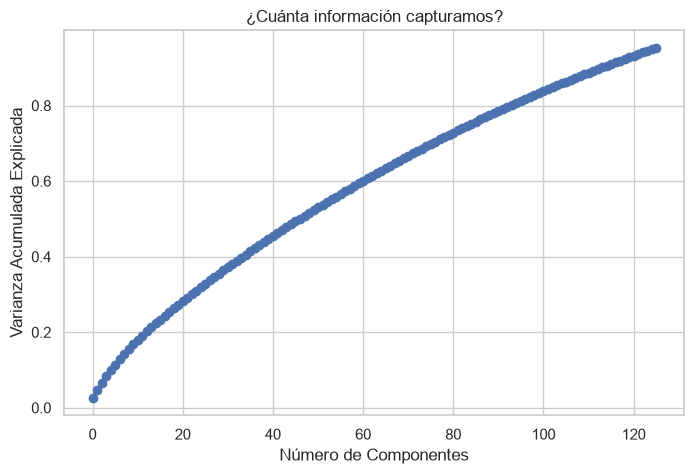

In [240]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('¿Cuánta información capturamos?')
plt.grid(True)
plt.show()

In [241]:
varianza_total = pca.explained_variance_ratio_.sum()
print(f"Varianza total explicada por estos componentes: {varianza_total:.2%}")
print(f'Número de componentes :   {pca.n_components_}')


Varianza total explicada por estos componentes: 95.28%
Número de componentes :   126


In [242]:
df_outliers_pca.to_parquet(f'{FOLDER_SALIDA}/df_outliers_pca(metricas_logs).parquet', index=False,engine='fastparquet')
df_ejecuciones_outlier.to_parquet(f'{FOLDER_SALIDA}/df_ejecuciones_outlier(metricas_logs).parquet', index=False,engine='fastparquet')

In [243]:
df_ejecuciones_outlier

,mse,execution_name
light-oauth2-data-1719677642.tar,0.293372,light-oauth2-data-1719677642.tar
light-oauth2-data-1719792847.tar,0.246092,light-oauth2-data-1719792847.tar
light-oauth2-data-1719857643.tar,0.297627,light-oauth2-data-1719857643.tar
light-oauth2-data-1719965648.tar,0.316867,light-oauth2-data-1719965648.tar
